# Movie Review Emotion Classification Using MLP
  
**Member:** IT25103132  
**Model:** Multi-Layer Perceptron (MLP)


The objective of this notebook is to train and evaluate
an MLP classifier to predict emotions from movie reviews.

The existing preprocessing methodology uses TF-IDF
feature extraction and TruncatedSVD dimensionality reduction.

This notebook focuses on:
1. Preparing the preprocessed features for model training
2. Training a Baseline MLP
3. Evaluating the baseline model
4. Handling class imbalance using Random Oversampling
5. Tuning the MLP using GridSearchCV
6. Evaluating and comparing the models

## 1. Project Setup

In [ ]:
!git clone https://github.com/it25102877/IT2011-AIML-Project.git

%cd /content/IT2011-AIML-Project

Cloning into 'IT2011-AIML-Project'...
remote: Enumerating objects: 624, done.
remote: Counting objects: 100% (218/218), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 624 (delta 142), reused 112 (delta 86), pack-reused 406 (from 1)
Receiving objects: 100% (624/624), 33.51 MiB | 23.06 MiB/s, done.
Resolving deltas: 100% (287/287), done.
/content/IT2011-AIML-Project


## 2. Import Required Libraries


In [ ]:
!pip -q install imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler

from src.data_prep import load_clean, make_split
from src.preprocessors import StopwordFilter

RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Load Cleaned Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Movies_Reviews_modified_version1.csv to Movies_Reviews_modified_version1.csv


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'IT2011-AIML-Project', 'sample_data']


## 3. Load Movie Review Dataset

In [ ]:
from pathlib import Path

csv_files = list(Path("/content").rglob("*.csv"))

for file in csv_files:
    print(file)

/content/IT2011-AIML-Project/Movies_Reviews_modified_version1.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_test.csv
/content/IT2011-AIML-Project/results/phase2/naive_bayes_test_predictions.csv
/content/IT2011-AIML-Project/results/phase2/random_forest_cv_results.csv
/content/IT2011-AIML-Project/results/phase2/hist_gradient_boosting_test_predictions.csv
/content/IT2011-AIML-Project/results/phase2/decision_tree_preprocessing_variants.csv
/content/IT2011-AIML-Project/results/phase2/decision_tree_test_predictions.csv
/content/IT2011-AIML-Project/results/phase2/random_forest_preprocessing_variants.csv
/content/IT2011-AIML-Project/results/phase2/random_forest_test_predictions.csv
/content/IT2011-AIML-Project/results/phase2/decision_tree_cv_results.csv
/content/IT2011-AIML-Project/results/outputs/processed_movie_reviews.csv
/content/IT2011-AIML-Project/results/phase2/

In [ ]:
import shutil
from pathlib import Path

# Find the uploaded movie review CSV
csv_files = [
    p for p in Path("/content").rglob("*.csv")
    if "Movies_Reviews_modified_version1" in p.name
]

if not csv_files:
    print("CSV not found. Please upload the file again.")
else:
    source = csv_files[0]

    destination = Path(
        "/content/IT2011-AIML-Project/data/raw/Movies_Reviews_modified_version1.csv"
    )

    destination.parent.mkdir(parents=True, exist_ok=True)

    if source.resolve() != destination.resolve():
        shutil.copy2(source, destination)

    print("Dataset connected successfully!")
    print("Source:", source)
    print("Destination:", destination)

Dataset connected successfully!
Source: /content/IT2011-AIML-Project/Movies_Reviews_modified_version1.csv
Destination: /content/IT2011-AIML-Project/data/raw/Movies_Reviews_modified_version1.csv


In [ ]:
df_clean = load_clean()

print("Dataset shape:", df_clean.shape)

print("\nEmotion distribution:")
print(df_clean["emotion"].value_counts())

display(df_clean.head())

Dataset shape: (16107, 9)

Emotion distribution:
emotion
sadness         6555
joy             2765
anticipation    2166
optimism        1772
fear            1386
anger            929
disgust          534
Name: count, dtype: int64


,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion,cleaned_review
0,0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation,it had some laughs but overall the motivation ...
1,1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation,waiting to exhale waiting and waiting and wait...
2,2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation,angela basset was good as expected but whitney...
3,3,5.0,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation,the movie is okay mediocre might even be the w...
4,4,5.0,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation,i got an opportunity to see waiting to exhale ...


## 4. Train and Test Data Preparation

In [ ]:
from src.data_prep import make_split

train_df, test_df = make_split(
    df_clean,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("Training movies:", train_df["movie_name"].nunique())
print("Testing movies:", test_df["movie_name"].nunique())

shared_movies = set(train_df["movie_name"]) & set(test_df["movie_name"])

print("Shared movies:", len(shared_movies))

assert len(shared_movies) == 0, "Data leakage detected!"

Training samples: 12873
Testing samples: 3234
Training movies: 1048
Testing movies: 261
Shared movies: 0


## 5. Feature Extraction Using TF-IDF and TruncatedSVD

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from src.preprocessors import StopwordFilter

train_df = train_df.copy()
test_df = test_df.copy()

stop_filter = StopwordFilter()

train_df["tokens_filtered"] = stop_filter.transform(
    train_df["cleaned_review"]
)

test_df["tokens_filtered"] = stop_filter.transform(
    test_df["cleaned_review"]
)

tfidf_vec = TfidfVectorizer(
    max_features=2500,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3
)

X_train_tfidf = tfidf_vec.fit_transform(
    train_df["tokens_filtered"]
)

X_test_tfidf = tfidf_vec.transform(
    test_df["tokens_filtered"]
)

svd_100 = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_train_svd = svd_100.fit_transform(X_train_tfidf)
X_test_svd = svd_100.transform(X_test_tfidf)

print("Train TF-IDF:", X_train_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)

print("Train SVD:", X_train_svd.shape)
print("Test SVD:", X_test_svd.shape)

Train TF-IDF: (12873, 2500)
Test TF-IDF: (3234, 2500)
Train SVD: (12873, 100)
Test SVD: (3234, 100)


## 6. Label Encoding


In [ ]:

import numpy as np

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(
    train_df["emotion"]
)

y_test = label_encoder.transform(
    test_df["emotion"]
)

print("Emotion classes:", label_encoder.classes_)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

for i, emotion in enumerate(label_encoder.classes_):
    print(i, "=", emotion)

Emotion classes: ['anger' 'anticipation' 'disgust' 'fear' 'joy' 'optimism' 'sadness']
Training labels: (12873,)
Testing labels: (3234,)
0 = anger
1 = anticipation
2 = disgust
3 = fear
4 = joy
5 = optimism
6 = sadness


## 7. Baseline MLP Model

In [ ]:
from sklearn.neural_network import MLPClassifier

baseline_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    random_state=42
)

baseline_mlp.fit(X_train_svd, y_train)

print("Baseline MLP trained successfully!")
print("Training iterations:", baseline_mlp.n_iter_)

Baseline MLP trained successfully!
Training iterations: 16


## 8. Baseline Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

y_pred_baseline = baseline_mlp.predict(X_test_svd)

baseline_accuracy = accuracy_score(
    y_test, y_pred_baseline
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="macro",
    zero_division=0
)

print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Baseline Macro F1:", round(baseline_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_baseline,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

Baseline Accuracy: 0.3837
Baseline Macro F1: 0.0861

Classification Report:
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       269
anticipation       0.00      0.00      0.00       457
     disgust       0.00      0.00      0.00       104
        fear       0.00      0.00      0.00       283
         joy       0.46      0.03      0.05       497
    optimism       0.00      0.00      0.00       389
     sadness       0.38      0.99      0.55      1235

    accuracy                           0.38      3234
   macro avg       0.12      0.15      0.09      3234
weighted avg       0.22      0.38      0.22      3234



## 9. Handle Class Imbalance

In [ ]:
!pip -q install imbalanced-learn

from imblearn.over_sampling import RandomOverSampler
import pandas as pd

ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train_svd,
    y_train
)

print("Before Oversampling:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nAfter Oversampling:")
print(pd.Series(y_train_resampled).value_counts().sort_index())

print("\nOriginal training shape:", X_train_svd.shape)
print("Resampled training shape:", X_train_resampled.shape)

Before Oversampling:
0     660
1    1709
2     430
3    1103
4    2268
5    1383
6    5320
Name: count, dtype: int64

After Oversampling:
0    5320
1    5320
2    5320
3    5320
4    5320
5    5320
6    5320
Name: count, dtype: int64

Original training shape: (12873, 100)
Resampled training shape: (37240, 100)


## 10. Oversampled MLP Training

In [ ]:
oversampled_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    random_state=42
)

oversampled_mlp.fit(
    X_train_resampled,
    y_train_resampled
)

print("Oversampled MLP trained successfully!")

Oversampled MLP trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## 11. Oversampled MLP Evaluation

In [ ]:
y_pred_oversampled = oversampled_mlp.predict(X_test_svd)

oversampled_accuracy = accuracy_score(
    y_test, y_pred_oversampled
)

oversampled_f1 = f1_score(
    y_test,
    y_pred_oversampled,
    average="macro",
    zero_division=0
)

print("Oversampled Accuracy:", round(oversampled_accuracy, 4))
print("Oversampled Macro F1:", round(oversampled_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_oversampled,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

Oversampled Accuracy: 0.1886
Oversampled Macro F1: 0.149

Classification Report:
              precision    recall  f1-score   support

       anger       0.10      0.12      0.11       269
anticipation       0.14      0.17      0.15       457
     disgust       0.03      0.05      0.04       104
        fear       0.10      0.14      0.12       283
         joy       0.19      0.24      0.21       497
    optimism       0.10      0.13      0.12       389
     sadness       0.42      0.23      0.30      1235

    accuracy                           0.19      3234
   macro avg       0.15      0.15      0.15      3234
weighted avg       0.24      0.19      0.20      3234



## 12. Hyperparameter Tuning Using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline

tuning_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=2500,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=3
    )),

    ("svd", TruncatedSVD(
        n_components=100,
        random_state=42
    )),

    ("mlp", MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=200,
        early_stopping=False,
        random_state=42
    ))
])

param_grid = {
    "mlp__hidden_layer_sizes": [(100,), (128, 64)],
    "mlp__alpha": [0.0001, 0.001],
    "mlp__learning_rate_init": [0.001, 0.0005]
}

group_cv = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=group_cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    train_df["tokens_filtered"],
    y_train,
    groups=train_df["movie_name"]
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters:
{'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.001}

Best Cross-Validation Macro F1:
0.1575


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## 13. Tuned MLP Evaluation

In [ ]:
best_mlp = grid_search.best_estimator_

y_pred_tuned = best_mlp.predict(
    test_df["tokens_filtered"]
)

tuned_accuracy = accuracy_score(
    y_test, y_pred_tuned
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="macro",
    zero_division=0
)

print("Tuned MLP Accuracy:", round(tuned_accuracy, 4))
print("Tuned MLP Macro F1:", round(tuned_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tuned,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

Tuned MLP Accuracy: 0.2415
Tuned MLP Macro F1: 0.146

Classification Report:
              precision    recall  f1-score   support

       anger       0.09      0.03      0.05       269
anticipation       0.15      0.13      0.14       457
     disgust       0.02      0.01      0.01       104
        fear       0.12      0.10      0.11       283
         joy       0.17      0.24      0.20       497
    optimism       0.12      0.11      0.11       389
     sadness       0.38      0.42      0.40      1235

    accuracy                           0.24      3234
   macro avg       0.15      0.15      0.15      3234
weighted avg       0.22      0.24      0.23      3234



## 14. Confusion Matrix

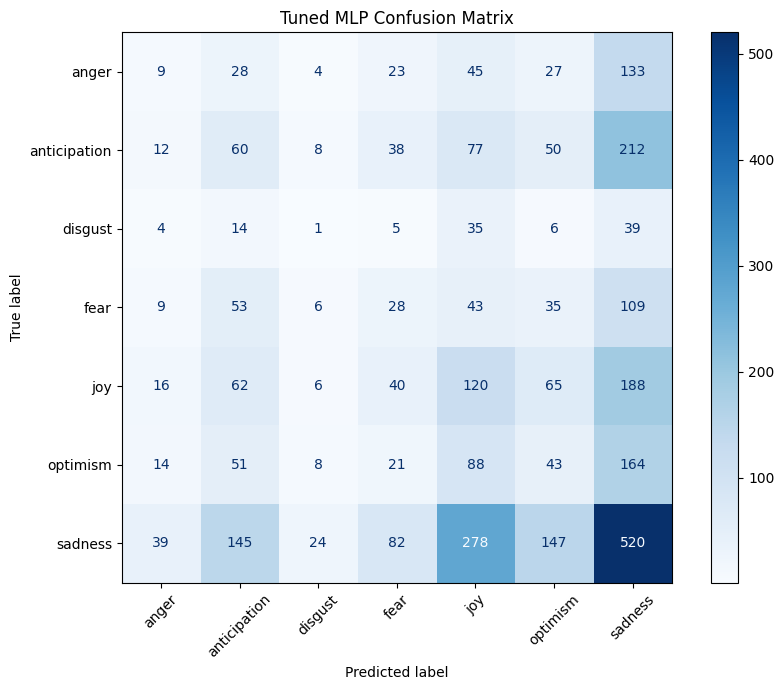

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=np.arange(len(label_encoder.classes_))
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Tuned MLP Confusion Matrix")
plt.tight_layout()
plt.show()

## 15. Model Performance Comparison

In [ ]:
results_df = pd.DataFrame({
    "Model": [
        "Baseline MLP",
        "Oversampled MLP",
        "Tuned MLP"
    ],
    "Accuracy": [
        baseline_accuracy,
        oversampled_accuracy,
        tuned_accuracy
    ],
    "Macro F1": [
        baseline_f1,
        oversampled_f1,
        tuned_f1
    ]
})

display(results_df.round(4))

best_row = results_df.loc[
    results_df["Macro F1"].idxmax()
]

print("Highest Test Macro F1:", best_row["Model"])
print("Score:", round(best_row["Macro F1"], 4))

,Model,Accuracy,Macro F1
0,Baseline MLP,0.3837,0.0861
1,Oversampled MLP,0.1886,0.1490
2,Tuned MLP,0.2415,0.1460


Highest Test Macro F1: Oversampled MLP
Score: 0.149


## 16. Performance Visualization

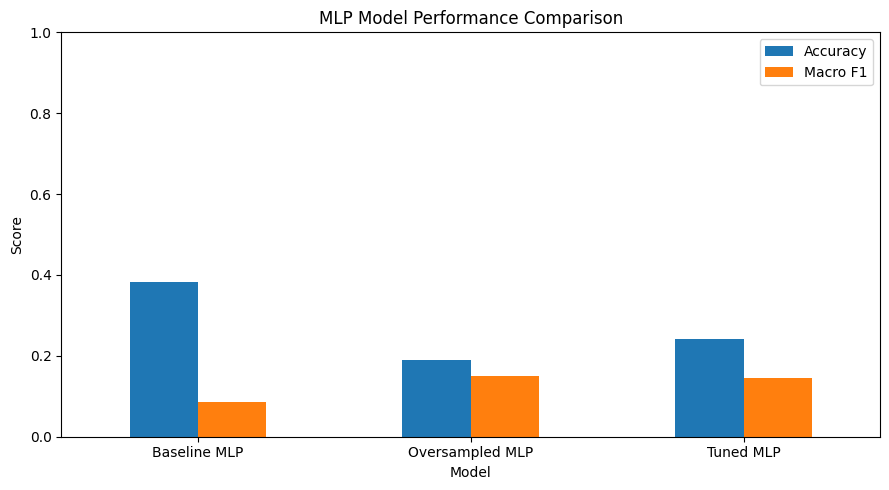

In [ ]:
results_df.set_index("Model")[
    ["Accuracy", "Macro F1"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("MLP Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

## 17. Save the Tuned MLP Model

In [ ]:
import joblib
from pathlib import Path

model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    best_mlp,
    model_dir / "member6_tuned_mlp.joblib"
)

joblib.dump(
    label_encoder,
    model_dir / "member6_label_encoder.joblib"
)

print("Model and label encoder saved successfully!")

Model and label encoder saved successfully!


## 18. Demonstrate Emotion Prediction

In [ ]:
# Demonstrate prediction using a review from the held-out test set
sample_review = test_df.iloc[0]["tokens_filtered"]
actual_emotion = test_df.iloc[0]["emotion"]

predicted_label = best_mlp.predict(
    pd.Series([sample_review])
)[0]

predicted_emotion = label_encoder.inverse_transform(
    [predicted_label]
)[0]

print("Processed Review:", str(sample_review)[:300])
print("Actual Emotion:", actual_emotion)
print("Predicted Emotion:", predicted_emotion)

Processed Review: laughs overall motivation incomprehensible mad men cheating sleep sorts married men hypocritical lives messed messed stupid choices empathy women
Actual Emotion: anticipation
Predicted Emotion: sadness


## 19. Conclusion

This notebook implemented and evaluated three MLP
configurations for movie review emotion classification.

1. Baseline MLP
2. Oversampled MLP
3. Tuned MLP using GridSearchCV



TF-IDF and TruncatedSVD were used for feature extraction,
while Random Oversampling was investigated as a method
for handling class imbalance.

Group-aware cross-validation was used during tuning to
prevent reviews from the same movie appearing in both
training and validation folds.

The models were evaluated using Accuracy, Macro F1-score,
classification reports, and a confusion matrix.

The final results should be interpreted based on the
observed scores and class-wise performance.